## Market Prior (Implied Returns) Validation — Black–Litterman

### Objective
Derive the **market-implied equilibrium returns** Pi and perform an **equilibrium check**:

- Compute the market prior via

Pi = lambda * Sigma * w_mkt

- Verify mathematical consistency by solving the mean–variance utility problem using (Pi, Sigma, lambda) and recovering w_mkt.

### Universe
['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'TSLA']

### Notation
- Sigma: (annualized) covariance matrix of returns
- w_mkt: market-cap weights (sum to 1)
- lambda: risk aversion
- Pi: implied equilibrium returns (annualized)


In [16]:
%reload_ext autoreload
%autoreload 2

%matplotlib inline

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure we run from project root (so `data/raw` resolves correctly)
if Path.cwd().name in {"notebooks", "research"}:
    os.chdir("..")

project_root = str(Path.cwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"CWD: {Path.cwd()}")

CWD: c:\Users\reymo\quant-portfolio


## Step 1 — Data acquisition (Adjusted Close)

We use the project’s storage layer (`DataManager`) to load OHLCV data from `data/raw`. 

We then build a clean price matrix P_t and compute simple daily returns:


R_t = (P_t / P_{t-1}) - 1



In [17]:
from src.data.data_manager import DataManager
from src.analytics.mvo_optimizer import MeanVarianceOptimizer
from src.analytics.black_litterman import BlackLittermanModel
import yfinance as yf

start_date = "2019-01-01"
end_date = "2023-12-31"

dm = DataManager(base_dir="data/raw")

tickers = dm.list_existing_tickers()

returns = dm.load_returns(tickers=tickers, start_date=start_date, end_date=end_date)

returns.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
AAPL,1033.000,0.001,0.021,-0.129,-0.009,0.000,0.012,0.120
ABBV,1033.000,0.001,0.016,-0.130,-0.007,0.001,0.008,0.087
ADBE,1033.000,0.001,0.024,-0.168,-0.011,0.001,0.014,0.177
AIR.PA,1033.000,0.000,0.028,-0.222,-0.011,0.001,0.012,0.205
AMZN,1033.000,0.001,0.023,-0.140,-0.012,0.000,0.013,0.135


## Step 2 — Covariance Sigma via Ledoit–Wolf shrinkage (project implementation)

We construct Sigma using the same shrinkage routine as the rest of the project (the stabilizer inside MeanVarianceOptimizer).

To keep units consistent with the benchmark return (8% annual), we **annualize** the covariance:

Sigma_ann = 252 * Sigma_daily


In [18]:
mvo = MeanVarianceOptimizer(returns)
delta = mvo.calculate_optimal_delta()

sigma_daily = mvo._apply_ledoit_wolf_shrinkage(delta)
Sigma_daily = pd.DataFrame(sigma_daily, index=tickers, columns=tickers)
Sigma_ann = 252.0 * Sigma_daily

delta, Sigma_ann.round(6).iloc[:3, :3]

(np.float64(0.025203636359241603),
       AAPL  ABBV  ADBE
 AAPL 0.110 0.028 0.087
 ABBV 0.028 0.063 0.028
 ADBE 0.087 0.028 0.150)

## Step 3 — Market weights w_mkt from market caps

We approximate the market portfolio over the universe by using current market capitalizations.


(w_mkt)_i = MktCap_i / (sum of all MktCap_j)


This yields a fully-invested benchmark vector aligned to (Sigma)’s index.


In [19]:
market_caps = dm.get_latest_market_cap(tickers).reindex(tickers)
w_mkt = (market_caps / market_caps.sum()).rename("w_mkt")

market_caps, w_mkt, w_mkt.sum()

(AAPL     2803317197106.934
 ABBV      253267895184.486
 ADBE      249736749780.273
 AIR.PA    106066783617.045
 AMZN     1624271446810.500
 ASML      288698312519.587
 AVGO      517534278337.883
 BABA      178095699624.002
 BNP.PA     59505447294.755
 CRM       247502103515.625
 CSCO      187453756949.514
 CVX       273239907107.531
 DG.PA      58212768673.059
 DIS       156944988347.136
 GOOGL    1677157975479.126
 HD        328555094866.424
 INTC      247690438199.874
 JNJ       355172250405.466
 JPM       440893133587.044
 KO        239046188183.640
 LIN       187737349967.193
 MA        376139192819.316
 MC.PA     349018397165.653
 MCD       201875924283.263
 META      889150402177.881
 MRK       255469052371.548
 MSFT     2753812279267.041
 NFLX      206529121189.058
 NKE       154387898785.002
 NVDA     1205040714653.015
 NVO       511095035982.444
 OR.PA     232689408834.290
 ORCL      295625033123.283
 PEP       216376400204.031
 PFE       141483292128.720
 PG        323212473

## Step 4 — Risk aversion lambda from a benchmark return and market variance

We use the standard CAPM-style approximation:

lambda = (E[R_mkt] - r_f) / Var(R_mkt)

Implementation details:
- E[R_mkt]: set to an annual benchmark return of **8%**.
- Var(R_mkt): estimated from the **variance of the market-portfolio return** of our universe using Sigma_ann:

Var(R_mkt) ≈ w_mkt^T * Sigma_ann * w_mkt


In [20]:
bl = BlackLittermanModel(risk_free_rate=0.04)

benchmark_return = 0.08
var_mkt = float(w_mkt.T @ Sigma_ann @ w_mkt)

lam = bl.calculate_risk_aversion(
    benchmark_return=benchmark_return, benchmark_var=var_mkt
)

pd.Series(
    {
        "rf": bl.rf,
        "benchmark_return": benchmark_return,
        "var_mkt": var_mkt,
        "lambda": lam,
    }
)

rf                 0.040
benchmark_return   0.080
var_mkt            0.063
lambda             0.634
dtype: float64

## Step 5 — Market prior (Implied returns) Pi

Given lambda, Sigma, and w_mkt, the equilibrium (market-implied) returns are

Pi = lambda * Sigma * w_mkt

Because we work with pandas objects, the multiplication is performed with **explicit index alignment** (same ticker ordering for Sigma and w_mkt).


In [21]:
Pi_ann = bl.calculate_implied_returns(
    covariance=Sigma_ann, market_weights=w_mkt, risk_aversion=lam
)

hist_ann = (returns.mean() * 252.0).rename("Historical Annualized Return")

pd.concat([hist_ann, Pi_ann], axis=1).head()

,Historical Annualized Return,Implied Returns
AAPL,0.291,0.046
ABBV,0.208,0.017
ADBE,0.217,0.049
AIR.PA,0.119,0.024
AMZN,0.184,0.044


## Step 6 — Equilibrium check (weight recovery)

We now solve the mean–variance utility problem:

maximize: Pi^T * w - (lambda/2) * w^T * Sigma * w
subject to: sum(w) = 1

If Pi = lambda * Sigma * w_mkt and constraints are not binding, the optimizer should recover the market weights:

w_optimized ≈ w_mkt


In [22]:
w_opt = mvo.solve(
    expected_returns=Pi_ann,
    covariance=Sigma_ann,
    risk_aversion=lam,
    long_only=True,
)

comparison = pd.concat([w_mkt.rename("w_mkt"), w_opt.rename("w_optimized")], axis=1)
comparison["abs_diff"] = (comparison["w_optimized"] - comparison["w_mkt"]).abs()

comparison.head(), comparison["abs_diff"].max()

(        w_mkt  w_optimized  abs_diff
 AAPL    0.126        0.126     0.000
 ABBV    0.011        0.011     0.000
 ADBE    0.011        0.011     0.000
 AIR.PA  0.005        0.005     0.000
 AMZN    0.073        0.073     0.000,
 np.float64(1.1939645697022633e-05))

## Step 7 — Visualizations

- **Return comparison**: historical annualized mean vs implied equilibrium return.
- **Weight recovery**: w_mkt vs w_optimized (should match up to numerical tolerance).


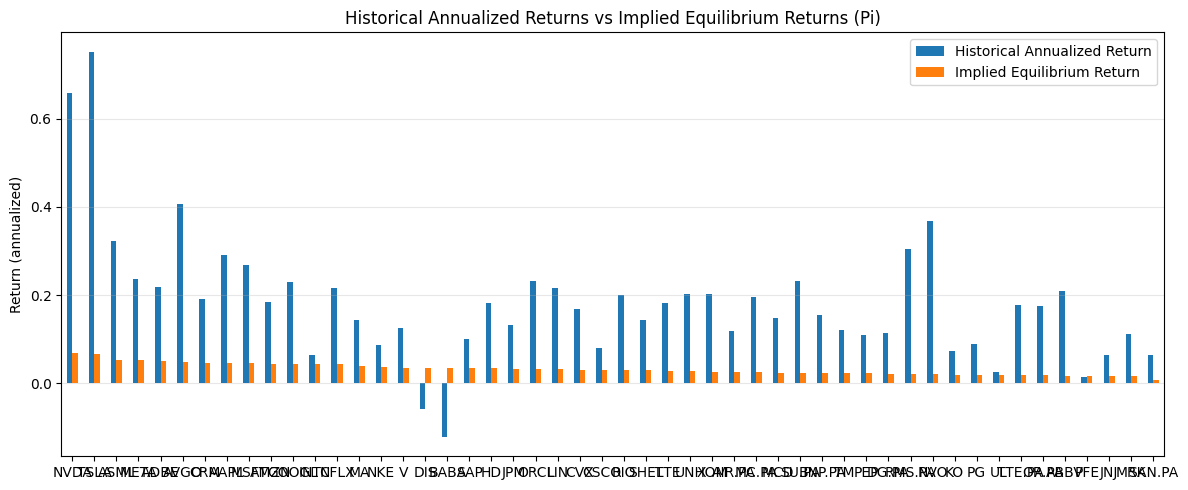

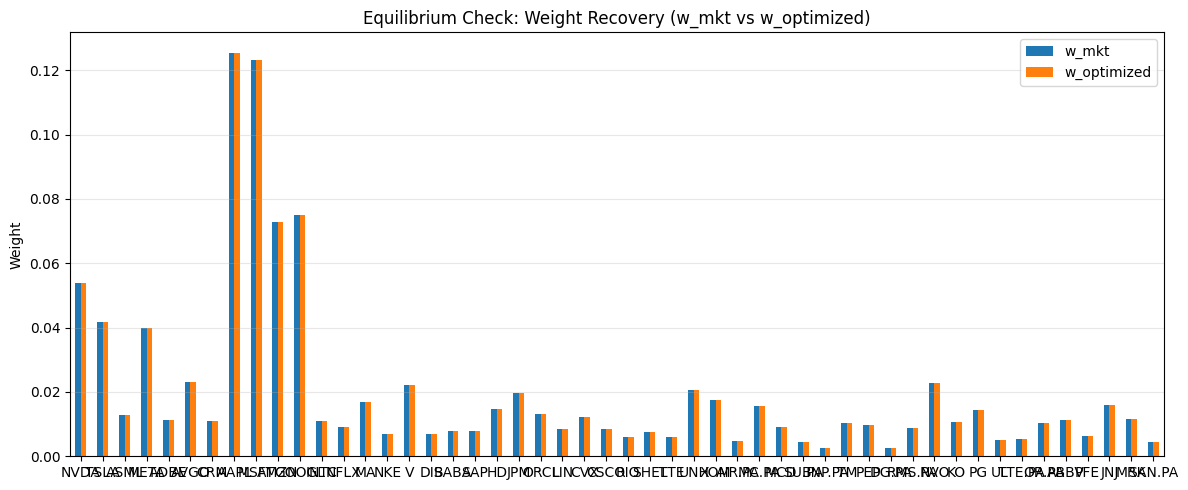

In [23]:
# --- Bar chart: Historical vs Implied ---
plot_df = pd.concat([hist_ann, Pi_ann.rename("Implied Equilibrium Return")], axis=1)
plot_df = plot_df.sort_values("Implied Equilibrium Return", ascending=False)

ax = plot_df.plot(kind="bar", figsize=(12, 5))
ax.set_title("Historical Annualized Returns vs Implied Equilibrium Returns (Pi)")
ax.set_ylabel("Return (annualized)")
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Weight recovery chart ---
weights_df = comparison[["w_mkt", "w_optimized"]].copy()
weights_df = weights_df.loc[plot_df.index]  # same ordering as plot above

ax = weights_df.plot(kind="bar", figsize=(12, 5))
ax.set_title("Equilibrium Check: Weight Recovery (w_mkt vs w_optimized)")
ax.set_ylabel("Weight")
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Interpretation

- If the **max absolute weight error** is near machine precision (e.g., (less than 10^-6)), the equilibrium identity is numerically validated under the project’s constraints.
- If the recovery is imperfect, the usual culprits are:
  - Unit mismatch (daily vs annual inputs),
  - Constraint binding (e.g., long-only causing corner solutions),
  - Index misalignment between (Sigma) and (w).


## Step 8 - Adding Views


In [24]:
tickers = dm.list_existing_tickers()
tau = 0.025
bl = BlackLittermanModel()
# Add Views
# View 1: Absolute - AAPL will return 7%
bl.add_view({"AAPL": 1.0}, 0.07, confidence_score=0.3)

# View 2: Relative Basket - (AAPL + MSFT) will outperform GOOGL by 2%
# Weights must sum to zero for relative trades
bl.add_view({"AAPL": 0.5, "MSFT": 0.5, "GOOGL": -1.0}, 0.02, confidence_score=0.5)

# 3. Generate Matrices
P, Q = bl._build_matrices(tickers)
Omega = bl.compute_omega(P, Sigma_ann.values, tau)

print("--- Pick Matrix (P) ---")
print(P)
print("\n--- View Vector (Q) ---")
print(Q)
print("\n--- Uncertainty Matrix (Omega) ---")
print(np.round(Omega, 6))

--- Pick Matrix (P) ---
[[ 1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.5  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  -1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.5  0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0. ]]

--- View Vector (Q) ---
[[0.07]
 [0.02]]

--- Uncertainty Matrix (Omega) ---
[[0.006414 0.      ]
 [0.       0.00124 ]]


In [25]:
E = bl.get_posterior_returns(Pi_ann, Sigma_ann, P, Q, Omega, tau)
E.head()

AAPL     0.055
ABBV     0.019
ADBE     0.055
AIR.PA   0.025
AMZN     0.047
dtype: float64

In [28]:
black_litterman_weights = mvo.solve(
    expected_returns=E, covariance=Sigma_ann, risk_aversion=lam, max_weights=0.25
)
tangency = mvo.find_tangency_portfolio(
    risk_free_rate=0.04, risk_free_rate_is_annual=True
)
portfolio_weights = tangency["weights"]


# Option B: If some are dicts, convert to Series with same index (tickers)
comparison = pd.DataFrame(
    {
        "market_weight": w_mkt,
        "tangency": pd.Series(
            portfolio_weights
        ),  # weights from get_optimal_weights is dict
        "black_litterman": black_litterman_weights,
    }
)

# Round to 3 decimals, then format so pandas doesn't use scientific notation
comparison_rounded = comparison.round(3)
pd.options.display.float_format = "{:.3f}".format
comparison_rounded.sort_values(by="market_weight", ascending=False, inplace=True)
comparison_rounded

,market_weight,tangency,black_litterman
AAPL,0.126,0.000,0.250
MSFT,0.123,0.000,0.225
GOOGL,0.075,0.000,0.000
AMZN,0.073,0.000,0.042
NVDA,0.054,0.138,0.053
TSLA,0.042,0.137,0.048
META,0.040,0.000,0.016
AVGO,0.023,0.000,0.035
NVO,0.023,0.383,0.010
V,0.022,0.000,0.027


In [27]:
# Pass the annualized covariance you used in the BL model
te_bl = mvo.compute_active_error(
    Sigma_ann, comparison["market_weight"], comparison["black_litterman"]
)
as_bl = mvo.compute_active_share(
    comparison["market_weight"], comparison["black_litterman"]
)

print(f"BL Active Share: {as_bl:.2%}")
print(f"BL Annualized Tracking Error: {te_bl:.2%}")

BL Active Share: 31.00%
BL Annualized Tracking Error: 4.27%
